In [17]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Step 0 — Inputs you assume you already have

## For each subject:

-   A list of that subject’s electrode locations (3D MNI coordinates)

## For each session:

-   A matrix of voltage time series: timepoints × electrodes

-   A list of all locations you want to index the final matrix by

In the paper, this is “all electrode locations from everyone pooled together” (union across subjects).

A smoothing width value (lambda), set to 20 in the paper.

In [18]:
# Each subjets electrode locations, registered to MNI space, in mm
aa_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/aa_xslocs_registered_mm.npy")
ap_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/ap_xslocs_registered_mm.npy")
ca_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/ca_xslocs_registered_mm.npy")
de_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/de_xslocs_registered_mm.npy")
fp_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/fp_xslocs_registered_mm.npy")
ha_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/ha_xslocs_registered_mm.npy")
ja_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/ja_xslocs_registered_mm.npy")
jm_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/jm_xslocs_registered_mm.npy")
jt_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/jt_xslocs_registered_mm.npy")
mv_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/mv_xslocs_registered_mm.npy")
rn_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/rn_xslocs_registered_mm.npy")
rr_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/rr_xslocs_registered_mm.npy")
wc_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/wc_xslocs_registered_mm.npy")
zt_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/zt_xslocs_registered_mm.npy")

### The order of the electrode numbers in the data should match the order of the electrode locations, so that you can compute distances between them and apply the weights correctly.

In [19]:
# each subjects preprocessed voltage time series, in microvolts, per electrode
project_root = Path('/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project')
preprocessed_dir = Path('/Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed')

subject_records = {}
for loc_path in sorted(preprocessed_dir.glob('*_locs_mni_mm.npy')):
    pid = loc_path.stem.split('_')[0]
    ecog_path = preprocessed_dir / f'{pid}_ecog_filtered.npy'
    stim_path = preprocessed_dir / f'{pid}_stim_nonzero.npy'
    if not ecog_path.exists() or not stim_path.exists():
        continue

    locs = np.load(loc_path).astype(np.float32, copy=False)
    ecog_shape = np.load(ecog_path, mmap_mode='r').shape
    stim_shape = np.load(stim_path, mmap_mode='r').shape

    subject_records[pid] = {
        'locs': locs,
        'ecog_path': ecog_path,
        'stim_path': stim_path,
    }
    print(f'[{pid}] locs={locs.shape} ecog={ecog_shape} stim={stim_shape}')

subject_ids = sorted(subject_records)
print(f'Loaded metadata for {len(subject_ids)} subjects from {preprocessed_dir}')

[aa] locs=(39, 3) ecog=(244200, 39) stim=(244200,)
[ap] locs=(40, 3) ecog=(241200, 40) stim=(241200,)
[ca] locs=(49, 3) ecog=(244200, 49) stim=(244200,)
[de] locs=(31, 3) ecog=(244200, 31) stim=(244200,)
[fp] locs=(50, 3) ecog=(244200, 50) stim=(244200,)
[ha] locs=(38, 3) ecog=(242200, 38) stim=(242200,)
[ja] locs=(54, 3) ecog=(244200, 54) stim=(244200,)
[jt] locs=(101, 3) ecog=(244200, 101) stim=(244200,)
[mv] locs=(58, 3) ecog=(244200, 58) stim=(244200,)
[rn] locs=(42, 3) ecog=(244240, 42) stim=(244240,)
[rr] locs=(40, 3) ecog=(162800, 40) stim=(162800,)
[wc] locs=(37, 3) ecog=(244200, 37) stim=(244200,)
[zt] locs=(56, 3) ecog=(244200, 56) stim=(244200,)
Loaded metadata for 13 subjects from /Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed


In [20]:
# All subjects' electrode locations in mni
all_locs_stack = np.vstack([subject_records[pid]['locs'] for pid in subject_ids])
_, first_idx = np.unique(all_locs_stack, axis=0, return_index=True)
all_electrodes = all_locs_stack[np.sort(first_idx)].astype(np.float32)
lambda_width = 20.0

print(f'Pooled unique electrode locations: {all_electrodes.shape}')
print(f'Gaussian smoothing width (lambda): {lambda_width}')

Pooled unique electrode locations: (532, 3)
Gaussian smoothing width (lambda): 20.0


# Step 1 — For each subject, compute “how correlated are that subject’s electrodes with each other?”

## Output: per subject, a square matrix: electrode × electrode correlation values.

FOR each subject:

    # 1A) compute a correlation matrix for each session
    session_correlation_matrices = []

    FOR each session:

        # voltages: timepoints × electrodes
        voltages = subject.session[session].voltages

        # compute Pearson correlation across electrodes (columns)
        corr_matrix = pearson_correlation_between_columns(voltages)

        session_correlation_matrices.append(corr_matrix)

    # 1B) average correlations across sessions using Fisher-z trick
    # (they do z-transform, average, then inverse transform) :contentReference[oaicite:3]{index=3}

    z_matrices = apply_fisher_z_to_each_matrix(session_correlation_matrices)
    mean_z = elementwise_average(z_matrices)
    subject_average_correlation_matrix = inverse_fisher_z(mean_z)

    save subject_average_correlation_matrix


Computed subject-level average electrode correlation matrices:
[aa] sessions=101 avg_corr_shape=(39, 39)
[ap] sessions=101 avg_corr_shape=(40, 40)
[ca] sessions=101 avg_corr_shape=(49, 49)
[de] sessions=101 avg_corr_shape=(31, 31)
[fp] sessions=101 avg_corr_shape=(50, 50)
[ha] sessions=101 avg_corr_shape=(38, 38)
[ja] sessions=101 avg_corr_shape=(54, 54)
[jt] sessions=101 avg_corr_shape=(101, 101)
[mv] sessions=101 avg_corr_shape=(58, 58)
[rn] sessions=101 avg_corr_shape=(42, 42)
[rr] sessions=101 avg_corr_shape=(40, 40)
[wc] sessions=101 avg_corr_shape=(37, 37)
[zt] sessions=101 avg_corr_shape=(56, 56)


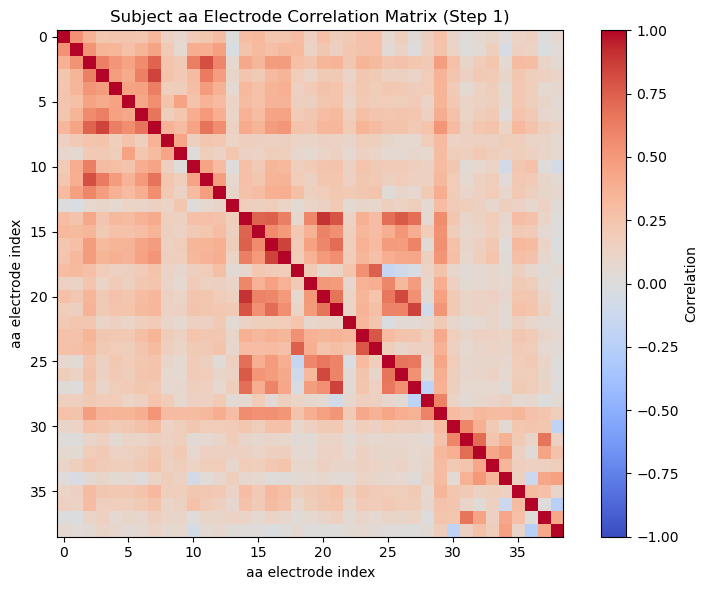

In [21]:
def fisher_z(corr_values):
    corr_values = np.clip(corr_values, -0.999999, 0.999999)
    return np.arctanh(corr_values)


def inverse_fisher_z(z_values):
    return np.tanh(z_values)


subject_session_correlation_matrices = {}
subject_average_correlation_matrices = {}

for pid in subject_ids:
    ecog = np.load(subject_records[pid]['ecog_path'], mmap_mode='r')
    stim = np.load(subject_records[pid]['stim_path']).ravel()

    session_corrs = []
    for stim_id in np.unique(stim):
        stim_mask = stim == stim_id
        if np.count_nonzero(stim_mask) < 2:
            continue

        session_data = ecog[stim_mask]
        corr_matrix = np.corrcoef(session_data, rowvar=False)
        corr_matrix = np.nan_to_num(corr_matrix, nan=0.0, posinf=0.0, neginf=0.0)
        np.fill_diagonal(corr_matrix, 1.0)
        session_corrs.append(corr_matrix.astype(np.float32, copy=False))

    if not session_corrs:
        raise ValueError(f'No valid session correlation matrices for subject {pid}')

    z_stack = fisher_z(np.stack(session_corrs, axis=0))
    mean_z = z_stack.mean(axis=0)
    subject_avg_corr = inverse_fisher_z(mean_z).astype(np.float32, copy=False)
    subject_avg_corr = 0.5 * (subject_avg_corr + subject_avg_corr.T)
    np.fill_diagonal(subject_avg_corr, 1.0)

    subject_session_correlation_matrices[pid] = session_corrs
    subject_average_correlation_matrices[pid] = subject_avg_corr

print('Computed subject-level average electrode correlation matrices:')
for pid in subject_ids:
    n_sessions = len(subject_session_correlation_matrices[pid])
    corr_shape = subject_average_correlation_matrices[pid].shape
    print(f'[{pid}] sessions={n_sessions} avg_corr_shape={corr_shape}')

if 'aa' in subject_average_correlation_matrices:
    aa_corr = subject_average_correlation_matrices['aa']
    plt.figure(figsize=(8, 6))
    im = plt.imshow(aa_corr, cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar(im, label='Correlation')
    plt.title('Subject aa Electrode Correlation Matrix (Step 1)')
    plt.xlabel('aa electrode index')
    plt.ylabel('aa electrode index')
    plt.tight_layout()
    plt.show()
else:
    print("Subject 'aa' not found; skipped Step 1 aa correlation plot.")

# Step 2 — For each subject, compute “how much does each of their electrodes inform each pooled location?”

## Output: for each subject, a table of weights:
pooled_location × subject_electrode

FOR each subject:

    subject_electrode_locations = subject.electrode_locations  # list of 3D coords
    pooled_locations = all_locations_across_all_subjects       # list of 3D coords

    # Make a weight table:
    # rows = pooled locations
    # cols = this subject's electrodes
    weights = zeros(num_pooled_locations, num_subject_electrodes)

    FOR each pooled_location_index, pooled_coord in pooled_locations:

        FOR each electrode_index, electrode_coord in subject_electrode_locations:

            distance_squared = squared_euclidean_distance(pooled_coord, electrode_coord)

            # Gaussian falloff (Eq. 1) :contentReference[oaicite:5]{index=5}
            weight = exp( -distance_squared / lambda )

            weights[pooled_location_index, electrode_index] = weight

    save weights


In [22]:
subject_weights = {}

for pid in subject_ids:
    subject_locs = subject_records[pid]['locs']

    diffs = all_electrodes[:, None, :] - subject_locs[None, :, :]
    distance_squared = np.sum(diffs * diffs, axis=2)
    weights = np.exp(-distance_squared / lambda_width).astype(np.float32, copy=False)

    subject_weights[pid] = weights

print('Computed pooled-location x subject-electrode weights:')
for pid in subject_ids:
    print(f'[{pid}] weights_shape={subject_weights[pid].shape}')

Computed pooled-location x subject-electrode weights:
[aa] weights_shape=(532, 39)
[ap] weights_shape=(532, 40)
[ca] weights_shape=(532, 49)
[de] weights_shape=(532, 31)
[fp] weights_shape=(532, 50)
[ha] weights_shape=(532, 38)
[ja] weights_shape=(532, 54)
[jt] weights_shape=(532, 101)
[mv] weights_shape=(532, 58)
[rn] weights_shape=(532, 42)
[rr] weights_shape=(532, 40)
[wc] weights_shape=(532, 37)
[zt] weights_shape=(532, 56)


# Step 3A — Subject-specific “full” matrix over pooled locations

## Goal: For a given subject, estimate correlation between any two pooled locations using:

that subject’s measured electrode correlations (Step 1)

the distance-based weights (Step 2)

FOR each subject:

    electrode_corr = subject_average_correlation_matrix   # electrodes × electrodes
    weights = subject_weights_table                       # pooled_locations × electrodes

    # subject_full_matrix is pooled_locations × pooled_locations
    subject_full_matrix = zeros(num_pooled_locations, num_pooled_locations)

    FOR each pooled_location_A in pooled_locations:

        FOR each pooled_location_B in pooled_locations:

            numerator_sum = 0
            denominator_sum = 0

            FOR each electrode_i in subject_electrodes:
                FOR each electrode_j in subject_electrodes:

                    # how much electrode i "represents" pooled_location_A
                    weight_A_i = weights[pooled_location_A, electrode_i]

                    # how much electrode j "represents" pooled_location_B
                    weight_B_j = weights[pooled_location_B, electrode_j]

                    pair_weight = weight_A_i * weight_B_j

                    # they Fisher-z the electrode correlations before averaging :contentReference[oaicite:7]{index=7}
                    corr_ij_z = fisher_z(electrode_corr[electrode_i, electrode_j])

                    numerator_sum   += pair_weight * corr_ij_z
                    denominator_sum += pair_weight

            # weighted average, then inverse Fisher-z (Eq. 6 idea) :contentReference[oaicite:8]{index=8}
            mean_z = numerator_sum / denominator_sum
            subject_full_matrix[pooled_location_A, pooled_location_B] = inverse_fisher_z(mean_z)

    save subject_full_matrix


In [23]:
subject_full_matrices = {}
eps = 1e-12

for pid in subject_ids:
    electrode_corr = subject_average_correlation_matrices[pid]
    weights = subject_weights[pid]

    corr_z = fisher_z(electrode_corr).astype(np.float32, copy=False)
    numerator = weights @ corr_z @ weights.T
    denominator = weights @ np.ones_like(corr_z, dtype=np.float32) @ weights.T

    mean_z = np.divide(
        numerator,
        denominator,
        out=np.zeros_like(numerator, dtype=np.float32),
        where=denominator > eps,
    )

    subject_full_matrix = inverse_fisher_z(mean_z).astype(np.float32, copy=False)
    subject_full_matrix = 0.5 * (subject_full_matrix + subject_full_matrix.T)
    np.fill_diagonal(subject_full_matrix, 1.0)

    subject_full_matrices[pid] = subject_full_matrix

print('Built subject-specific pooled-location correlation matrices:')
for pid in subject_ids:
    print(f'[{pid}] full_matrix_shape={subject_full_matrices[pid].shape}')

Built subject-specific pooled-location correlation matrices:
[aa] full_matrix_shape=(532, 532)
[ap] full_matrix_shape=(532, 532)
[ca] full_matrix_shape=(532, 532)
[de] full_matrix_shape=(532, 532)
[fp] full_matrix_shape=(532, 532)
[ha] full_matrix_shape=(532, 532)
[ja] full_matrix_shape=(532, 532)
[jt] full_matrix_shape=(532, 532)
[mv] full_matrix_shape=(532, 532)
[rn] full_matrix_shape=(532, 532)
[rr] full_matrix_shape=(532, 532)
[wc] full_matrix_shape=(532, 532)
[zt] full_matrix_shape=(532, 532)


# Step 3B — Average the subject-specific full matrices to get the across-subject matrix

collect all subject_full_matrix objects: one per subject
all_subject_full_matrices = [...]

Fisher-z them, average them elementwise, inverse Fisher-z (Eq. 7) :contentReference[oaicite:9]{index=9}
z_mats = fisher_z(all_subject_full_matrices)
mean_z = elementwise_average(z_mats)
across_subject_correlation_matrix = inverse_fisher_z(mean_z)


Across-subject matrix summary:
shape=(532, 532)
min=-0.0559 max=1.0000
diag_min=1.0000 diag_max=1.0000
max_symmetry_error=0.000000


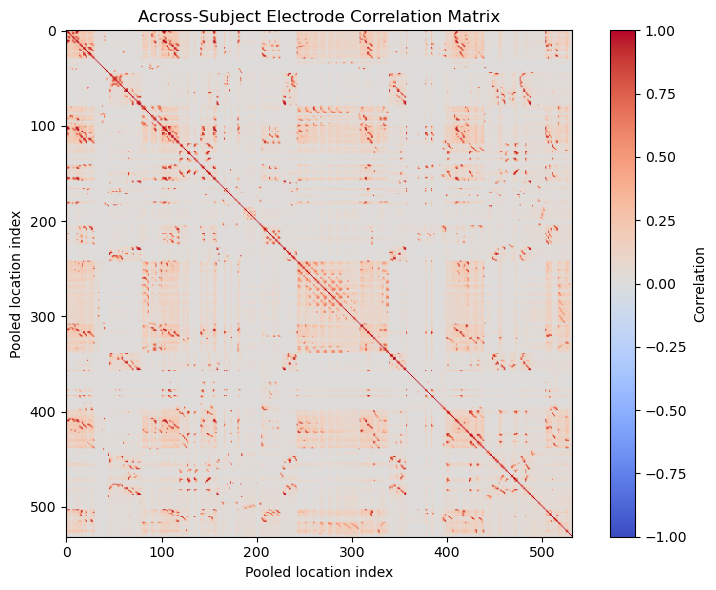

Saved outputs to /Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/electrode_correlation_outputs.npz


In [24]:
all_subject_full_matrices = np.stack([subject_full_matrices[pid] for pid in subject_ids], axis=0)

mean_z = fisher_z(all_subject_full_matrices).mean(axis=0)
across_subject_correlation_matrix = inverse_fisher_z(mean_z).astype(np.float32, copy=False)
across_subject_correlation_matrix = 0.5 * (across_subject_correlation_matrix + across_subject_correlation_matrix.T)
np.fill_diagonal(across_subject_correlation_matrix, 1.0)

print('Across-subject matrix summary:')
print(f'shape={across_subject_correlation_matrix.shape}')
print(f'min={across_subject_correlation_matrix.min():.4f} max={across_subject_correlation_matrix.max():.4f}')
print(f'diag_min={np.diag(across_subject_correlation_matrix).min():.4f} diag_max={np.diag(across_subject_correlation_matrix).max():.4f}')
print(f'max_symmetry_error={np.abs(across_subject_correlation_matrix - across_subject_correlation_matrix.T).max():.6f}')

plt.figure(figsize=(8, 6))
im = plt.imshow(across_subject_correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, label='Correlation')
plt.title('Across-Subject Electrode Correlation Matrix')
plt.xlabel('Pooled location index')
plt.ylabel('Pooled location index')
plt.tight_layout()
plt.show()

output_path = project_root / 'electrode_correlation_outputs.npz'
np.savez_compressed(
    output_path,
    pooled_locations_mni_mm=all_electrodes,
    subject_ids=np.array(subject_ids, dtype=object),
    subject_full_matrices=all_subject_full_matrices,
    across_subject_correlation_matrix=across_subject_correlation_matrix,
)
print(f'Saved outputs to {output_path}')